In [59]:
# Import core libraries for data manipulation and plotting (pandas, numpy, matplotlib, seaborn).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# Load fear/greed index CSV into df1 and display head.
df1 = pd.read_csv('fear_greed_index.csv')
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [61]:
#Load historical trades CSV into df2 and display head.
df2 = pd.read_csv('historical_data.csv')
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [62]:
# Parse date/time columns in df1 and df2 to datetime dtype.
df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'], format='%d-%m-%Y %H:%M')

In [63]:
# Create date-only columns (trade_date, sentiment_date) for joining.
df2['trade_date'] = df2['Timestamp IST'].dt.date
df1['sentiment_date'] = df1['date'].dt.date

In [64]:
# Define mapping from sentiment labels to numeric scores.
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

In [65]:
# Map classification to sentiment_score in df1. 
df1['sentiment_score'] = df1['classification'].map(sentiment_map)

In [66]:
# Select relevant columns: fear_greed_df and historical_data_df. 
fear_greed_df = df1[['sentiment_date','sentiment_score', 'classification']]
historical_data_df = df2[['Account','Coin','Execution Price','Size Tokens','Size USD','Side','Closed PnL','Direction','trade_date']]

In [67]:
#  Inspect first rows of fear_greed_df. 
fear_greed_df.head()

,sentiment_date,sentiment_score,classification
0,2018-02-01,1,Fear
1,2018-02-02,0,Extreme Fear
2,2018-02-03,1,Fear
3,2018-02-04,0,Extreme Fear
4,2018-02-05,0,Extreme Fear


In [68]:
# Inspect first rows of historical_data_df.
historical_data_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Direction,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.0,Buy,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,0.0,Buy,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,0.0,Buy,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,0.0,Buy,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,0.0,Buy,2024-12-02


In [69]:
# Merge the two DataFrames on the date columns
# Left-join trades with daily sentiment on trade_date → sentiment_date.
merged_df = pd.merge(
    historical_data_df,
    fear_greed_df,
    left_on='trade_date',
    right_on='sentiment_date',
    how='left'
)
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Direction,trade_date,sentiment_date,sentiment_score,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed


In [70]:
# checking the number of trades with and without sentiment 
# Count total trades and how many have matched/unmatched sentiment.  
total_trades = len(merged_df)
matched_sentiment = merged_df['sentiment_score'].notna().sum()
unmatched_sentiment = total_trades - matched_sentiment
print(f"Total Trades: {total_trades}")
print(f"Matched Sentiment: {matched_sentiment}")
print(f"Unmatched Sentiment: {unmatched_sentiment}")
merged_df.head()

Total Trades: 211224
Matched Sentiment: 211218
Unmatched Sentiment: 6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Direction,trade_date,sentiment_date,sentiment_score,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,0.0,Buy,2024-12-02,2024-12-02,4.0,Extreme Greed


In [71]:
merged_df.to_csv('merged_data.csv', index=False)
print("Merged data saved to 'merged_data.csv'")
# Save the merged DataFrame to a CSV file

Merged data saved to 'merged_data.csv'


In [72]:
# Create PnL_bin to label trades as Profit / Loss / Zero
merged_df['PnL_bin'] = np.where(
    merged_df['Closed PnL'] > 0, 'Profit',
    np.where(merged_df['Closed PnL'] < 0, 'Loss', 'Zero')
)


In [73]:
# Aggregate trader-level performance metrics and filter out traders with <10 trades.

trader_summary = (
    merged_df
    .groupby("Account")
    .agg(
        total_pnl=("Closed PnL", "sum"),           # Total profit/loss per trader
        total_trades=("Closed PnL", "count"),      # Number of trades per trader
        avg_trade_size_usd=("Size USD", "mean")    # Average trade size in USD (Leverage column not available)
    )
    .reset_index()
)

# Removing traders with very few trades to reduce noise
trader_summary = trader_summary[trader_summary["total_trades"] >= 10]


In [74]:
# Defining profitability thresholds using total PnL percentiles
top_20 = trader_summary["total_pnl"].quantile(0.8)     # Top 20% traders
bottom_20 = trader_summary["total_pnl"].quantile(0.2) # Bottom 20% traders

# Function to assign trader category
def trader_label(pnl):
    if pnl >= top_20:
        return "Profitable"
    elif pnl <= bottom_20:
        return "Losing"
    else:
        return "Average"

# Applying trader labels
trader_summary["trader_type"] = trader_summary["total_pnl"].apply(trader_label)

# Merge trader categories back into the main merged dataset
merged_df = merged_df.merge(
    trader_summary[["Account", "trader_type"]],
    on="Account",
    how="left"
)
trader_summary.head()

,Account,total_pnl,total_trades,avg_trade_size_usd,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,Profitable
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,Average
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898,Losing
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,Average
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782,Average


In [75]:
# Analyze trader behavior by sentiment and trader type
# Group by trader_type and sentiment to compute avg_pnl, avg_trade_size_usd, trade_count.
segmented_analysis = (
    merged_df
    .groupby(["trader_type", "classification"])
    .agg(
        avg_pnl=("Closed PnL", "mean"),          # Average PnL per trade
        avg_trade_size_usd=("Size USD", "mean"), # Average trade size
        trade_count=("Closed PnL", "count")      # Number of trades
    )
    .reset_index()
)

segmented_analysis
  

,trader_type,classification,avg_pnl,avg_trade_size_usd,trade_count
0,Average,Extreme Fear,82.042905,4966.608182,3855
1,Average,Extreme Greed,37.626967,2903.889793,29806
2,Average,Fear,38.131404,3062.870189,14742
3,Average,Greed,28.440532,2674.714236,29154
4,Average,Neutral,9.722783,3047.282693,15807
5,Losing,Extreme Fear,-25.202776,9115.430797,5306
6,Losing,Extreme Greed,75.793000,3590.286848,387
7,Losing,Fear,32.942518,10590.308651,9286
8,Losing,Greed,-182.438038,5978.524101,2446
9,Losing,Neutral,21.153896,8219.539603,2320


In [76]:
# Feature engineering: Side_Binary, Trade_Imapct, Closed_PnL_Numeric, Normalized_PnL. 
# Convert 'Side' to binary 
merged_df['Side_Binary'] = merged_df['Side'].apply(lambda x : 1 if str(x).upper() == 'BUY' else 0)
# Trade Impact (proxy for exposure)
merged_df['Trade_Impact'] = merged_df['Size USD']
# Normalized PnL = PnL/Size USD (Risk Adjusted return)
merged_df['Closed_PnL_Numeric'] = historical_data_df['Closed PnL']
merged_df['Normalized_PnL'] = merged_df.apply(
    lambda row : row['Closed_PnL_Numeric'] / row['Size USD'] if row['Size USD'] else 0, axis=1
)

In [77]:
# Show sample rows of engineered features to validate transformations.
merged_df[['Account', 'trade_date', 'Side', 'Side_Binary', 'Size USD',
           'Closed PnL', 'PnL_bin', 'Trade_Impact', 'Normalized_PnL','classification']].head()

,Account,trade_date,Side,Side_Binary,Size USD,Closed PnL,PnL_bin,Trade_Impact,Normalized_PnL,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,BUY,1,7872.16,0.0,Zero,7872.16,0.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,BUY,1,127.68,0.0,Zero,127.68,0.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,BUY,1,1150.63,0.0,Zero,1150.63,0.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,BUY,1,1142.04,0.0,Zero,1142.04,0.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,BUY,1,69.75,0.0,Zero,69.75,0.0,Extreme Greed


In [78]:
# Account_Level Daily Aggregation by sentiment and compute Profit_Rate.

daily_account_stats = merged_df.groupby(['Account', 'trade_date', 'classification', 'sentiment_score']).agg({
    'Closed PnL': ['sum', 'mean'],
    'Size USD': ['sum', 'mean'],
    'Side_Binary': 'mean',  
    'PnL_bin': lambda x: (x == 'Profit').sum(),  
    'Account': 'count'  
}).reset_index()

daily_account_stats.columns = [
    'Account', 'trade_date', 'classification', 'sentiment_score',
    'Total_PnL', 'Avg_PnL',
    'Total_Trade_Size', 'Avg_Trade_Size',
    'Buy_Ratio',
    'Profit_Trades',
    'Total_Trades'
]

daily_account_stats['Profit_Rate'] = daily_account_stats['Profit_Trades'] / daily_account_stats['Total_Trades']
daily_account_stats.head()

,Account,trade_date,classification,sentiment_score,Total_PnL,Avg_PnL,Total_Trade_Size,Avg_Trade_Size,Buy_Ratio,Profit_Trades,Total_Trades,Profit_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,4.0,0.0,0.000000,900880.13,5089.718249,0.000000,0,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,4.0,0.0,0.000000,542413.18,7976.664412,0.000000,0,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,4.0,0.0,0.000000,949380.00,23734.500000,0.000000,0,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,4.0,-21227.0,-1768.916667,338240.00,28186.666667,1.000000,0,12,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,4.0,1603.1,59.374074,465700.00,17248.148148,0.444444,12,27,0.444444


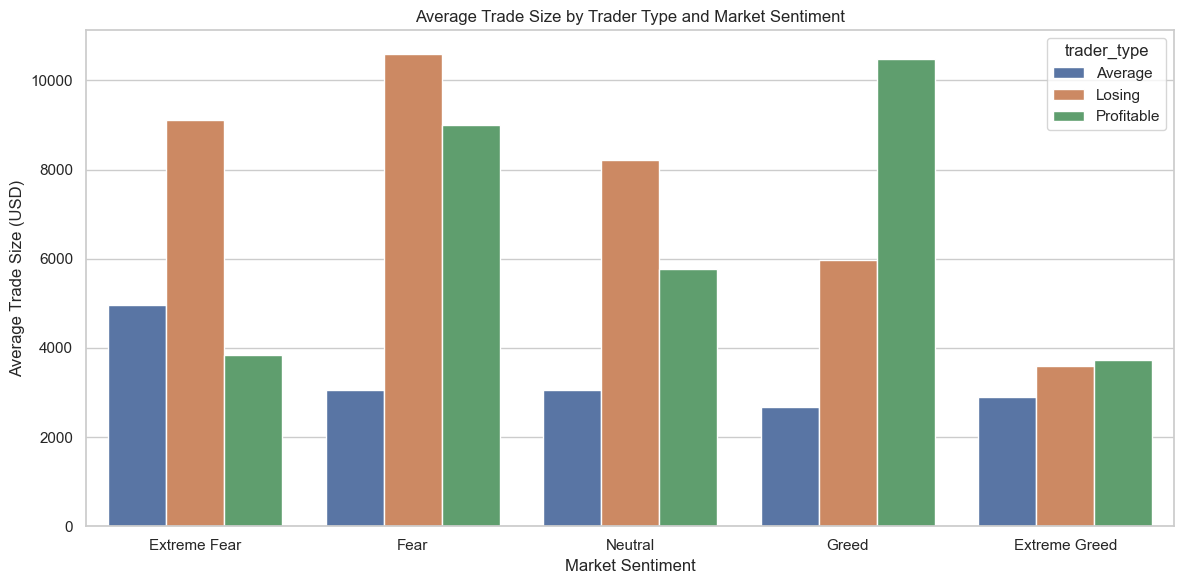

In [79]:
# Bar plot showing average trade size by sentiment and trader type
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

sns.barplot(
    data=segmented_analysis,
    x="classification",
    y="avg_trade_size_usd",
    hue="trader_type",
    order=sentiment_order
)

plt.title("Average Trade Size by Trader Type and Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.tight_layout()
plt.show()


C:\Users\DeLL\AppData\Local\Temp\ipykernel_21272\677907177.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_account_stats, x='classification', y='Avg_PnL', palette='coolwarm')


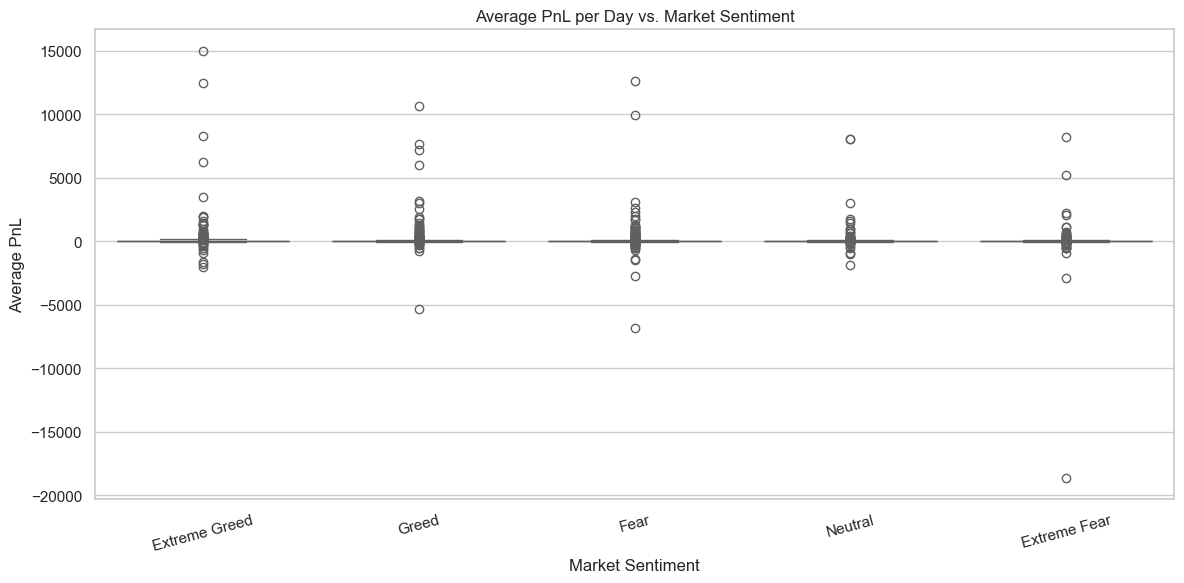

C:\Users\DeLL\AppData\Local\Temp\ipykernel_21272\677907177.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_account_stats, x='classification', y='Profit_Rate', palette='viridis')


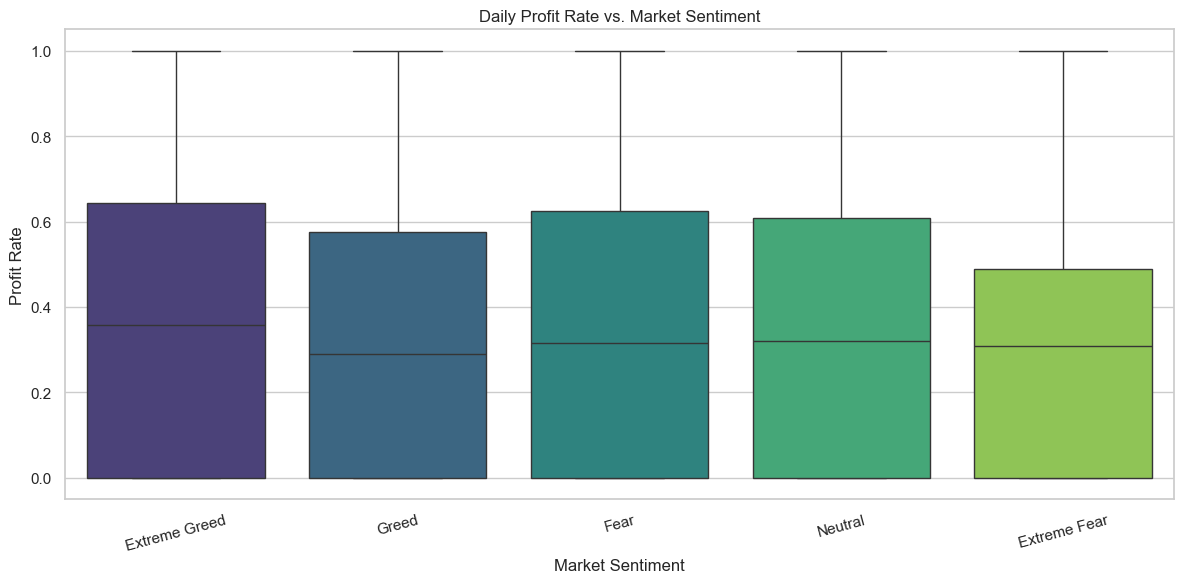

C:\Users\DeLL\AppData\Local\Temp\ipykernel_21272\677907177.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_account_stats, x='classification', y='Buy_Ratio', palette='Set2')


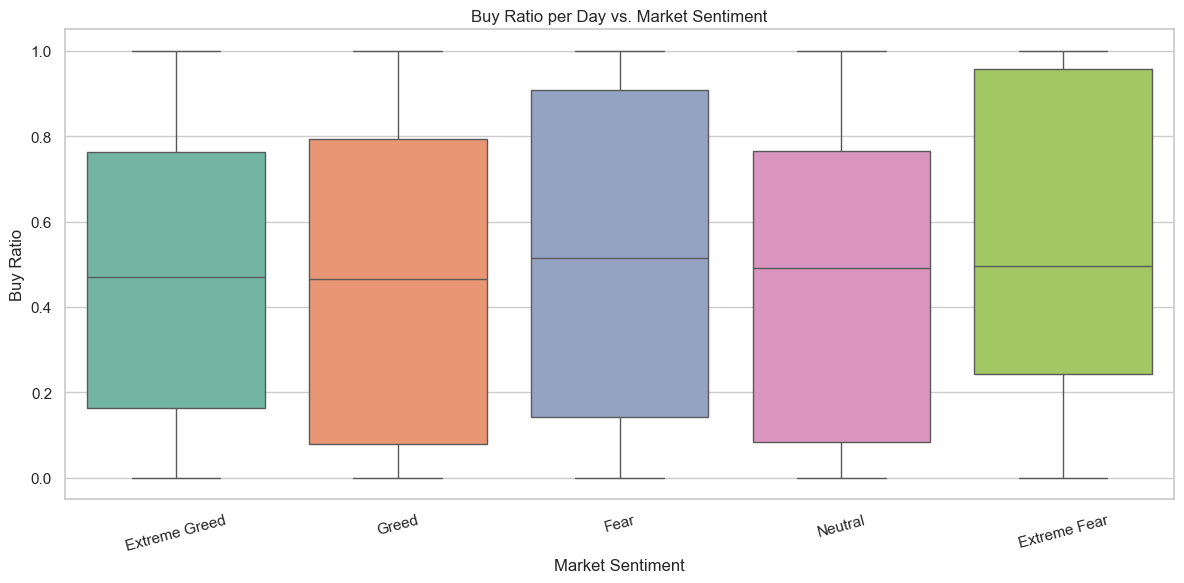

In [80]:
# Boxplots: Avg_PnL, Profit_Rate, and Buy_Ratio across sentiment classes.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Plot 1: Average PnL per Sentiment Class 
plt.figure()
sns.boxplot(data=daily_account_stats, x='classification', y='Avg_PnL', palette='coolwarm')
plt.title('Average PnL per Day vs. Market Sentiment')
plt.ylabel('Average PnL')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 2: Profit Rate vs. Sentiment Class
plt.figure()
sns.boxplot(data=daily_account_stats, x='classification', y='Profit_Rate', palette='viridis')
plt.title('Daily Profit Rate vs. Market Sentiment')
plt.ylabel('Profit Rate')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 3: Buy Ratio vs. Sentiment Class
plt.figure()
sns.boxplot(data=daily_account_stats, x='classification', y='Buy_Ratio', palette='Set2')
plt.title('Buy Ratio per Day vs. Market Sentiment')
plt.ylabel('Buy Ratio')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
